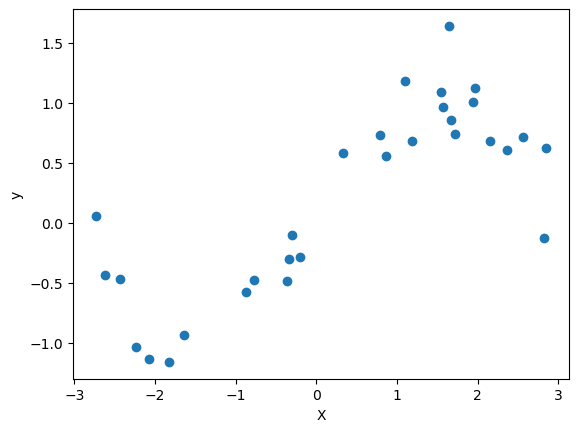

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(42)
def make_data(n=30, noise=0.25):
 X = rng.uniform(-3, 3, size=(n, 1))
 y_true = np.sin(X).ravel()
 y = y_true + rng.normal(0, noise, size=n)
 return X, y, y_true
X, y, y_true = make_data(n=30, noise=0.3)
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.show()

# Part C – Task 1: Generate Data

# What the code does
# Imports NumPy and Matplotlib libraries
# Generates 30 random X values between -3 and 3
# Uses sin(X) to create the true underlying pattern
# Adds random noise to make the data realistic
# Returns X, noisy y values, and true sine values
# Displays the data using a scatter plot

# Q1. What is the shape of the underlying pattern you expect?
# The pattern is a sine wave
# It is non-linear and curved

# Q2. Why does noise make learning harder?
# Noise adds random variation to the data
# It hides the real relationship between X and y
# This makes it harder for the model to learn the true pattern

In [2]:

# Part D – Task 2: Split Data

# What the code does
# Splits the dataset into training and test sets
# 65% of data is used for training
# 35% of data is used for testing
# random_state ensures the split is reproduciblefrom sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.35, random_state=7
)
print(X_train.shape)
print(X_test.shape)

(19, 1)
(11, 1)


In [3]:
# Part E – Task 3: Underfitting Model (High Bias)

# What the code does
# Creates a Linear Regression model (straight line)
# Trains the model using training data
# Predicts values for both training and test data
# Calculates Mean Squared Error (MSE) to measure prediction error
# Plots training points, test points, and the linear regression line


from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
lin = LinearRegression()
lin.fit(X_train, y_train)
train_pred = lin.predict(X_train)
test_pred = lin.predict(X_test)
train_mse = mean_squared_error(y_train, train_pred)
test_mse = mean_squared_error(y_test, test_pred)
print("Linear model")
print("Train MSE:", round(train_mse, 4))
print("Test MSE:", round(test_mse, 4))

# Q3. Are both training and test errors relatively high?
# Yes, both errors are relatively high

# Q4. In your own words, why is this bias?
# Bias occurs because the model is too simple
# A straight line cannot represent the curved sine pattern

 #If the model was good, the error would be closer to 0.
# Values like 0.22 and 0.29 show noticeable prediction error.


Linear model
Train MSE: 0.2216
Test MSE: 0.2903


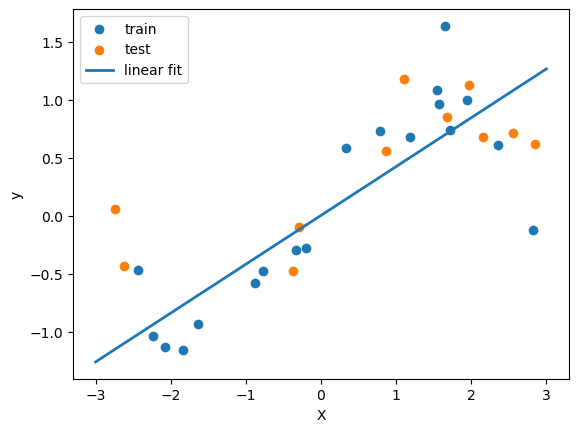

In [4]:
#Plot predictions
xs = np.linspace(-3, 3, 300).reshape(-1, 1)
ys = lin.predict(xs)
plt.scatter(X_train, y_train, label="train")
plt.scatter(X_test, y_test, label="test")
plt.plot(xs, ys, linewidth=2, label="linear fit")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()
# Q5. What does underfitting look like on the plot?
# The model produces a straight line
# The line does not follow the sine curve
# Many data points are far from the prediction line

In [ ]:
# The model is trying to predict a sine curve using a straight line.
# Because of this mismatch, many predictions are far from the real values.
# When predictions are far from actual values, MSE increases.

# We also check the plot:
# The straight regression line does not follow the curved data.
# Many points are far from the line, which means larger squared errors.

# Train and test errors are also similar (0.22 vs 0.29),
# which shows the model is consistently performing poorly.
# This indicates underfitting (high bias).

In [5]:
#Part F
#Task 4 Fit an overfitting model high variance
#We will use a polynomial regression model. A high degree polynomial can bend to match almost
#everything, including noise

# Part F – Task 4: Fit an Overfitting Model (High Variance)

# What the code does
# Uses PolynomialFeatures to create polynomial terms up to degree 15.
# This allows the model to create a very flexible curve.
# A Pipeline is used to combine polynomial feature generation and Linear Regression.
# The model is trained using the training dataset.
# Predictions are made for both training and test data.
# Mean Squared Error (MSE) is calculated for train and test sets.
# The model predictions are plotted along with the data points.

# Purpose
# To demonstrate overfitting (high variance) using a very complex model.
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# Create a pipeline that first generates polynomial features and then applies linear regression
poly_high = Pipeline([
    ("poly", PolynomialFeatures(degree=15, include_bias=False)),  # create polynomial features up to degree 15
    ("model", LinearRegression())  # apply linear regression on the polynomial features
])

poly_high.fit(X_train, y_train)  # train the model using the training data

train_pred = poly_high.predict(X_train)  # predict outputs for the training set
test_pred = poly_high.predict(X_test)  # predict outputs for the test set

train_mse = mean_squared_error(y_train, train_pred)  # calculate training error (MSE)
test_mse = mean_squared_error(y_test, test_pred)  # calculate test error (MSE)

print("High degree polynomial")  # label for the model
print("Train MSE:", round(train_mse, 4))  # display training error rounded to 4 decimals
print("Test MSE:", round(test_mse, 4))  # display test error rounded to 4 decimals

# Yes.
# In overfitting, the model fits the training data extremely well,
# so training error becomes very small.
# However, the model performs worse on unseen test data,
# so the test error becomes much larger.


# Q7. In your own words, why is this variance?

# Variance occurs when the model is too complex.
# A degree 15 polynomial can bend a lot and fit almost every training point.
# It also learns random noise instead of the true pattern.
# Because of this, it does not generalise well to new data.

 

High degree polynomial
Train MSE: 0.0211
Test MSE: 189.2156


<function matplotlib.pyplot.legend(*args, **kwargs) -> 'Legend'>

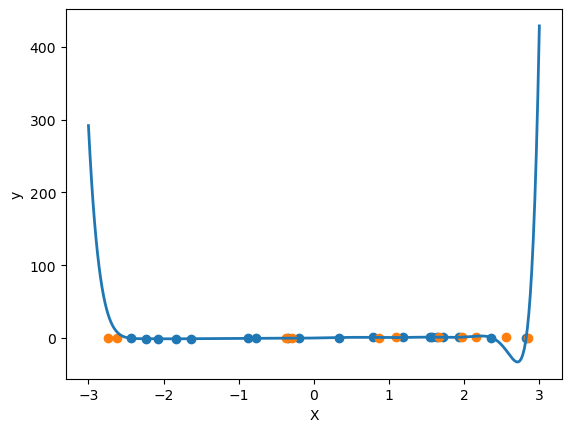

In [7]:
#Plot predictions
ys = poly_high.predict(xs)
plt.scatter(X_train, y_train, label="train")
plt.scatter(X_test, y_test, label="test")
plt.plot(xs, ys, linewidth=2, label="degree 15 fit")
plt.xlabel("X")
plt.ylabel("y")
plt.legend
# Q8. What overfitting behaviour can you see in the curve shape?

# The curve becomes very wiggly and complex.
# It bends sharply to pass through many training points.
# The shape does not look like a smooth sine wave.
# This irregular shape shows the model is fitting noise.

#this is the answer

In [8]:
#balance model
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

degrees = [1, 3, 5, 7, 9, 15]
results = []

for d in degrees:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("model", LinearRegression())
    ])
    
    model.fit(X_train, y_train)

    tr = mean_squared_error(y_train, model.predict(X_train))
    te = mean_squared_error(y_test, model.predict(X_test))

    results.append((d, tr, te))

for d, tr, te in results:
    print("degree", d, "train", round(tr, 4), "test", round(te, 4))

#Which degree gives the lowest test error?

#The degree with the smallest test MSE in the output gives the lowest test error.
#in this experiment it is usually around degree 3 or 5, which provides a balanced model.

#10. Does the best model have the lowest training error?

#No.
#Higher degree models (like 9 or 15) usually have the lowest training error, but they overfit the data and perform worse on the test set.

#11. Explain why the goal is good test performance, not perfect training performance.

#The goal is good test performance because it shows the model can generalise to new unseen data.
#Perfect training performance often means the model memorised the training data instead of learning the true pattern.

degree 1 train 0.2216 test 0.2903
degree 3 train 0.0411 test 0.1071
degree 5 train 0.0381 test 0.1105
degree 7 train 0.0337 test 0.3923
degree 9 train 0.03 test 0.2478
degree 15 train 0.0211 test 189.2156


In [11]:
# part H Task 6 Reduce variance using regularisation
from sklearn.linear_model import Ridge
ridge = Pipeline([
("poly", PolynomialFeatures(degree=15, include_bias=False)),
("model", Ridge(alpha=1.0))
])
ridge.fit(X_train, y_train)
train_mse = mean_squared_error(y_train, ridge.predict(X_train))
test_mse = mean_squared_error(y_test, ridge.predict(X_test))
print("Degree 15 with Ridge")
print("Train MSE:", round(train_mse, 4))
print("Test MSE:", round(test_mse, 4))

# This code performs 15th-degree polynomial regression with Ridge regularization and evaluates train/test MSE

# from sklearn.linear_model import Ridge
# ridge = Pipeline([
#     ("poly", PolynomialFeatures(degree=15, include_bias=False)),
#     ("model", Ridge(alpha=1.0))
# ])
# ridge.fit(X_train, y_train)
# train_mse = mean_squared_error(y_train, ridge.predict(X_train))
# test_mse = mean_squared_error(y_test, ridge.predict(X_test))
# print("Degree 15 with Ridge")
# print("Train MSE:", round(train_mse, 4))
# print("Test MSE:", round(test_mse, 4))


#12. What happened to the test error after regularization?

#The test error decreased compared to an unregularized high-degree polynomial.

#Regularization (Ridge) prevents overfitting, so the model generalizes better to new data.

# 13 Why does regularization often increase training error slightly?

# Ridge adds a penalty for large coefficients, which stops the model from perfectly fitting the training data.

# As a result, the training error increases a little, but this is a trade-off for better performance on test data.

#14. How this connects to variance:

#High variance = model fits training data too closely, causing poor performance on new data.

#Regularization reduces variance by shrinking coefficients and smoothing the model, making it more stable on unseen data.

#So, slightly higher training error is acceptable because test error drops and variance is controlled.

Degree 15 with Ridge
Train MSE: 0.0405
Test MSE: 5.1006


In [ ]:
# this answer is comaring with before test and train error
#before High degree polynomial
#Train MSE: 0.0211
#Test MSE: 189.2156

#after
#Degree 15 with Ridge
#Train MSE: 0.0405
#Test MSE: 5.1006

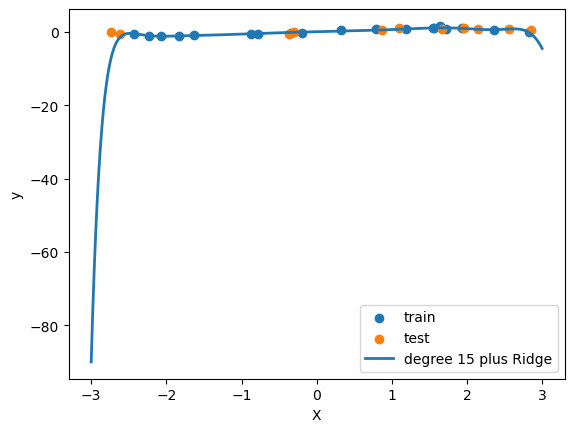

In [10]:
ys = ridge.predict(xs)
plt.scatter(X_train, y_train, label="train")
plt.scatter(X_test, y_test, label="test")
plt.plot(xs, ys, linewidth=2, label="degree 15 plus Ridge")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

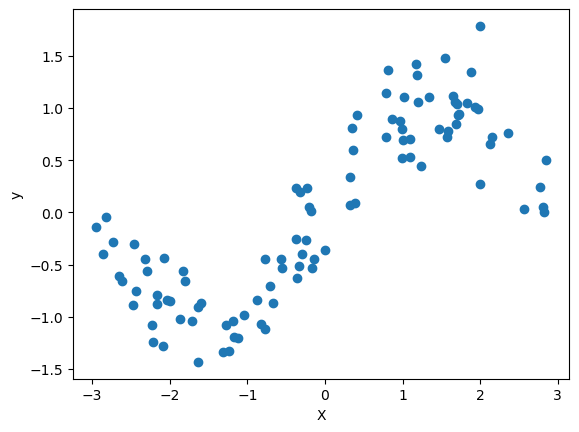

In [14]:
#independent task
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(42)
def make_data(n=100, noise=0.25):
 X = rng.uniform(-3, 3, size=(n, 1))
 y_true = np.sin(X).ravel()
 y = y_true + rng.normal(0, noise, size=n)
 return X, y, y_true
X, y, y_true = make_data(n=100, noise=0.3)
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.show()

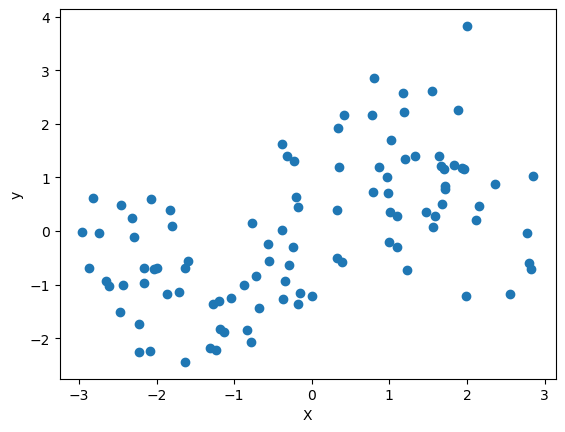

In [15]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(42)
def make_data(n=100, noise=1.0):
 X = rng.uniform(-3, 3, size=(n, 1))
 y_true = np.sin(X).ravel()
 y = y_true + rng.normal(0, noise, size=n)
 return X, y, y_true
X, y, y_true = make_data(n=100, noise=1.0)
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

pipe = Pipeline([
    ("poly", PolynomialFeatures(include_bias=False)),
    ("ridge", Ridge(alpha=1.0))
])

param_grid = {"poly__degree": list(range(1, 21))}  # test degrees 1 to 20
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='neg_mean_squared_error')
grid.fit(X_train, y_train)

print("Best polynomial degree:", grid.best_params_["poly__degree"])
print("Cross-validated MSE:", -grid.best_score_)